In [1]:
import pandas as pd
df = pd.read_csv('C:\\Users\\User\\OneDrive\\Desktop\\NCA\\data\\netflix_cleaned.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,25
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,24
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,24
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,24


Movies vs TV shows

In [2]:
type_counts = df['type'].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

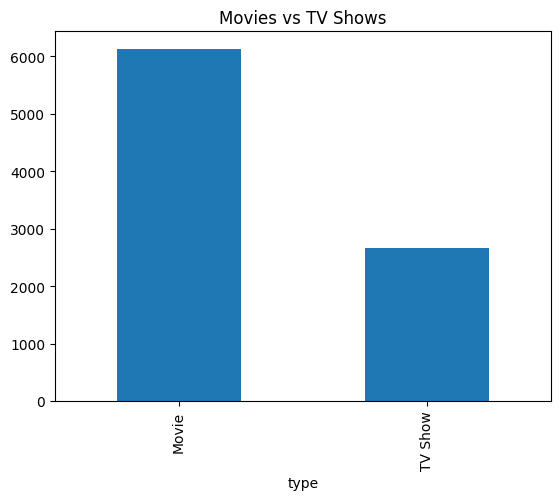

In [4]:
type_counts.plot(
    kind='bar'
)

plt.title('Movies vs TV Shows')
plt.show()

Content Added Each Year

In [5]:
yearly = df['added_year'].value_counts().sort_index()

yearly

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

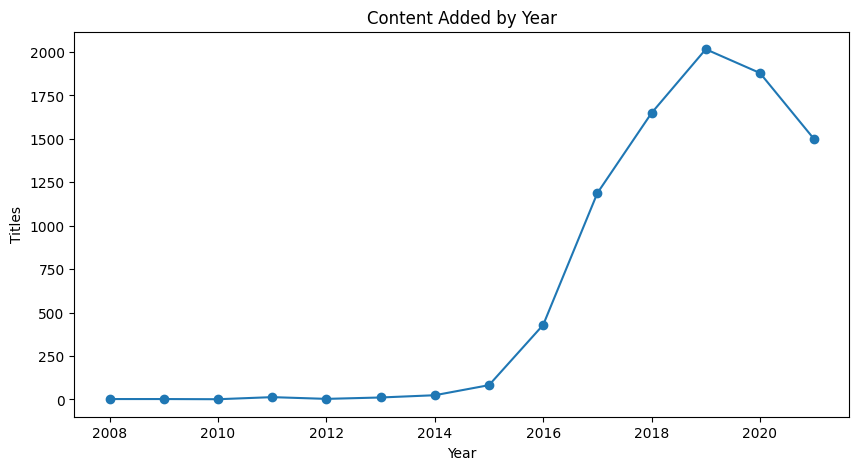

In [6]:
plt.figure(figsize=(10,5))

yearly.plot(kind='line', marker='o')

plt.title('Content Added by Year')

plt.xlabel('Year')

plt.ylabel('Titles')

plt.show()

Top 10 Countries

In [7]:
countries = df.assign(
    country=df['country'].str.split(', ')
).explode('country')

In [8]:
top_countries = countries['country'].value_counts().head(10)

print(top_countries)

country
United States     3683
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


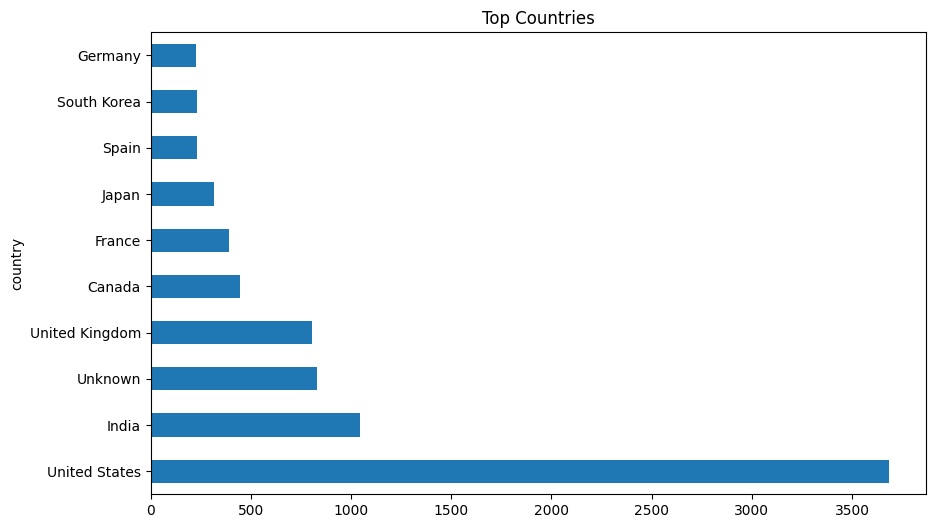

In [9]:
plt.figure(figsize=(10,6))

top_countries.plot(kind='barh')

plt.title('Top Countries')

plt.show()

Top Genres

In [10]:
genres = df.assign(
    genre=df['listed_in'].str.split(', ')
).explode('genre')

In [11]:
top_genres = genres['genre'].value_counts().head(10)

In [12]:
top_genres = genres['genre'].value_counts().head(10)

top_genres

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

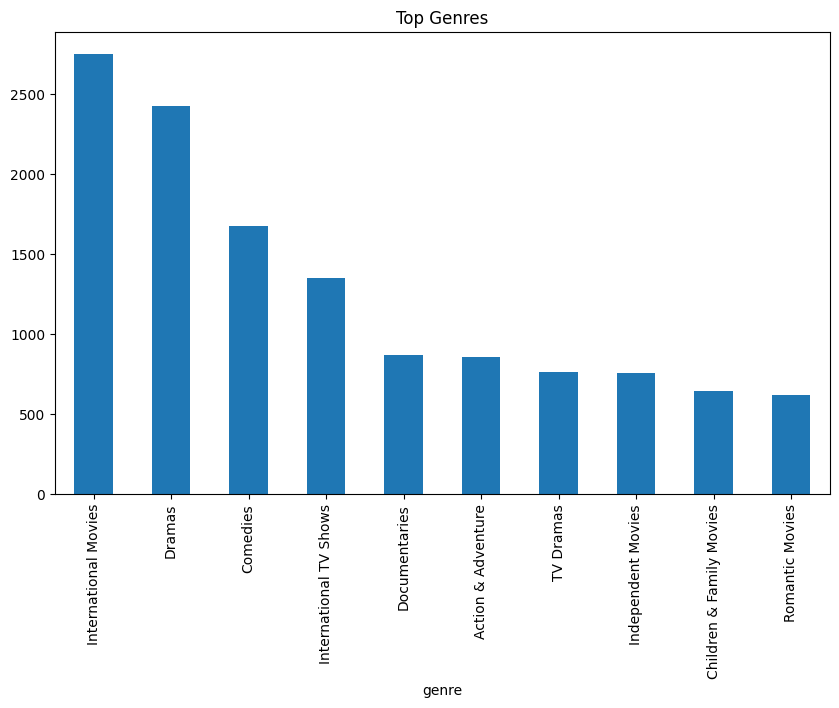

In [13]:
plt.figure(figsize=(10,6))

top_genres.plot(kind='bar')

plt.title('Top Genres')

plt.show()

Rating Distribution

In [14]:
rating_counts = df['rating'].value_counts()

rating_counts

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64

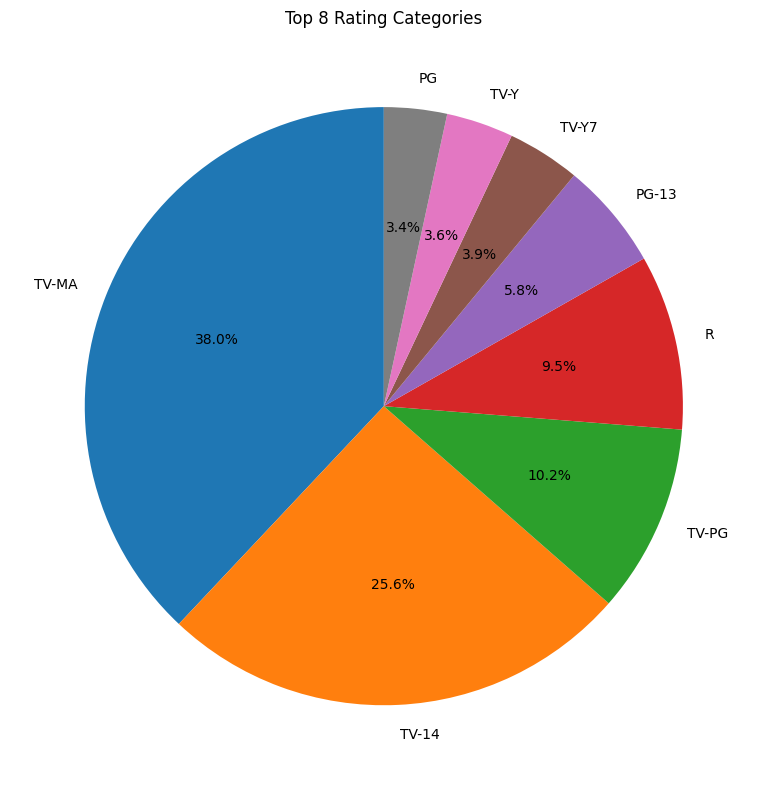

In [15]:
import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts()

top_ratings = rating_counts.head(8)

plt.figure(figsize=(10, 8))

plt.pie(
    top_ratings,
    labels=top_ratings.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 8 Rating Categories')
plt.tight_layout()
plt.show()

Top directors

In [16]:
top_directors = df['director'].value_counts().head(10)

top_directors

director
Unknown                   2624
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Youssef Chahine             12
Jay Chapman                 12
Name: count, dtype: int64

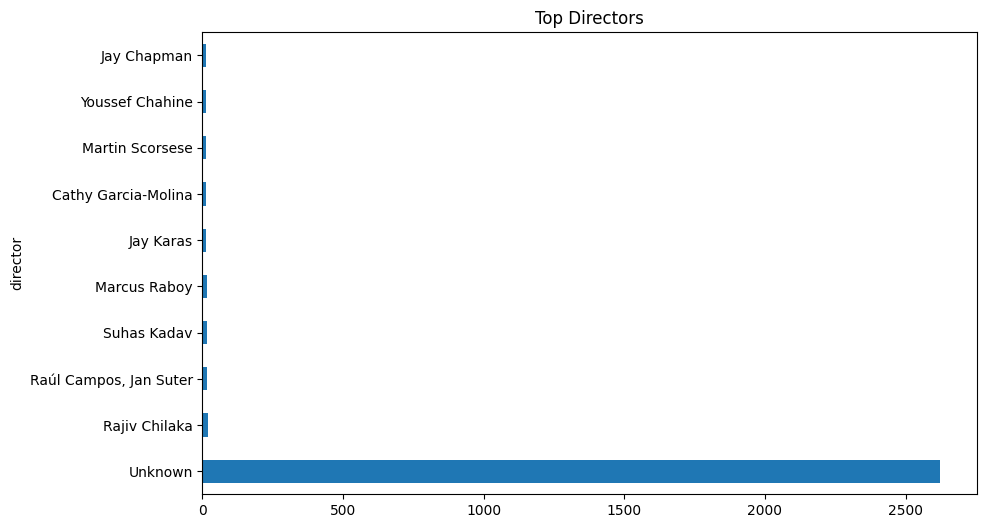

In [17]:
plt.figure(figsize=(10,6))

top_directors.plot(kind='barh')

plt.title('Top Directors')

plt.show()

Movie Duration Distribution

In [18]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)')
movies['duration_min'] = pd.to_numeric(
    movies['duration_min'],
    errors='coerce'
)

movies = movies.dropna(subset=['duration_min'])

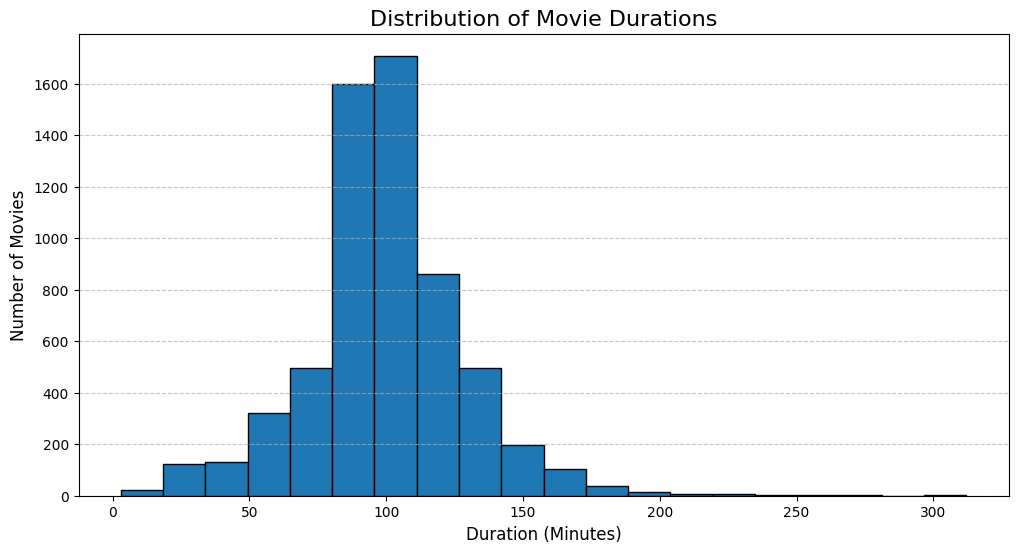

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hist(
    movies['duration_min'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Movie Durations', fontsize=16)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Release Year Trend

In [21]:
release_trend = df['release_year'].value_counts().sort_index()

release_trend

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

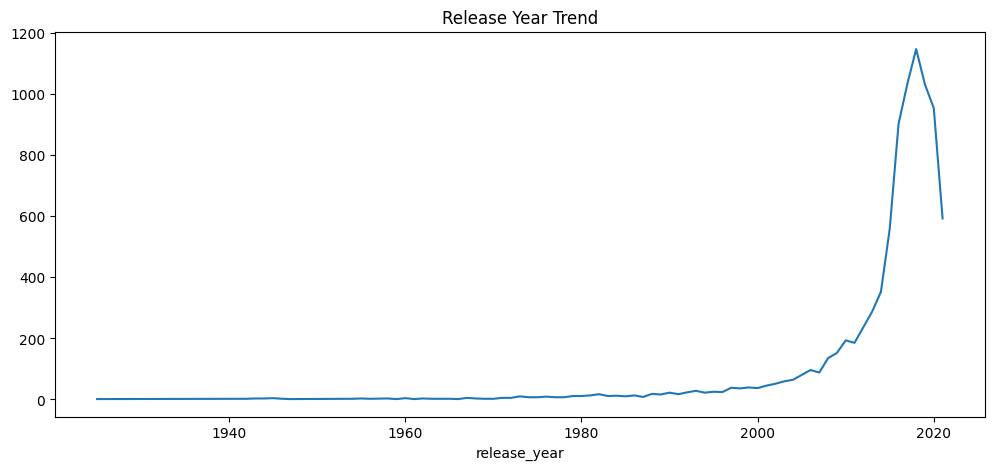

In [22]:
plt.figure(figsize=(12,5))

release_trend.plot(kind='line')

plt.title('Release Year Trend')

plt.show()

Average Movie Duration

In [23]:
movies['duration_min'].mean()

np.float64(99.57718668407311)

Longest Movies

In [24]:
movies.sort_values(
    by='duration_min',
    ascending=False
)[['title','duration_min']].head(10)

,title,duration_min
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7923,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


Export Clean Dataset

In [25]:
df.to_csv(
    'C:\\Users\\User\\OneDrive\\Desktop\\NCA\\data\\netflix_cleaned.csv',
    index=False
)

Save Important Tables for Dashboard

In [68]:
top_genres.to_csv("top_genres.csv")

top_countries.to_csv("top_countries.csv")

top_directors.to_csv("top_directors.csv")

In [69]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'added_year', 'added_month', 'added_day'],
      dtype='object')